# 1. Data Overview

In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

sys.path.insert(0, str(Path("/app")))

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
print("start eda")

start eda


In [3]:
from source.utils.db import load_enriched_trip_data

df = load_enriched_trip_data()
df.head()

,pulocationid,dolocationid,year,month,day_of_week,hour,num_trips,avg_fare_amount,total_fare_amount,avg_total_amount,avg_trip_distance,avg_trip_time,avg_tolls_amount,total_tolls_amount,avg_tip_amount,total_tip_amount,avg_airport_fee,total_airport_fee,avg_congestion_surcharge,total_congestion_surcharge,avg_cbd_congestion_fee,total_cbd_congestion_fee,avg_extra,total_extra,avg_total_fee,row_fingerprint,pu_borough,pu_zone,pu_service_zone,do_borough,do_zone,do_service_zone,avg_temperature_mean,avg_precipitation_sum,avg_wind_speed_max,rainy_days_count,num_days
0,237,229,2023,12,6,5,1,7.2,7.2,14.03,1.09,237.0,0.0,0.0,1.83,1.83,0.0,0.0,2.5,2.5,None,None,2.5,2.5,None,d5e4d6162346727b64da93a8e26acc7e92589c7ae6d2b5...,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Sutton Place/Turtle Bay North,Yellow Zone,5.74,0.16,14.58,3,5
1,186,162,2023,12,6,7,1,15.6,15.6,22.10,1.95,939.0,0.0,0.0,2.50,2.50,0.0,0.0,2.5,2.5,None,None,1.5,1.5,None,aad461ec8c11b5ee042aa15fda30b2c5bb853e5c071226...,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,Midtown East,Yellow Zone,5.74,0.16,14.58,3,5
2,163,75,2023,12,6,7,1,15.6,15.6,24.50,2.16,1007.0,0.0,0.0,4.90,4.90,0.0,0.0,2.5,2.5,None,None,1.5,1.5,None,c6228a72d14c6b37bd471b4c20d85b630aa78442ba573f...,Manhattan,Midtown North,Yellow Zone,Manhattan,East Harlem South,Boro Zone,5.74,0.16,14.58,3,5
3,249,231,2023,12,6,7,1,8.6,8.6,15.12,1.49,342.0,0.0,0.0,2.52,2.52,0.0,0.0,2.5,2.5,None,None,1.5,1.5,None,35c606df0fd365f12f13eff2ff0bab18f6a03abd9ac7bb...,Manhattan,West Village,Yellow Zone,Manhattan,TriBeCa/Civic Center,Yellow Zone,5.74,0.16,14.58,3,5
4,114,234,2023,12,6,7,1,9.3,9.3,17.29,1.00,452.0,0.0,0.0,3.99,3.99,0.0,0.0,2.5,2.5,None,None,1.5,1.5,None,06a14ee7acf72c65ee48580a59860eadea219957984444...,Manhattan,Greenwich Village South,Yellow Zone,Manhattan,Union Sq,Yellow Zone,5.74,0.16,14.58,3,5


In [21]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282045 entries, 0 to 282044
Data columns (total 37 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   pulocationid                282045 non-null  int64  
 1   dolocationid                282045 non-null  int64  
 2   year                        282045 non-null  int64  
 3   month                       282045 non-null  int64  
 4   day_of_week                 282045 non-null  int64  
 5   hour                        282045 non-null  int64  
 6   num_trips                   282045 non-null  int64  
 7   avg_fare_amount             282045 non-null  float64
 8   total_fare_amount           282045 non-null  float64
 9   avg_total_amount            282045 non-null  float64
 10  avg_trip_distance           282045 non-null  float64
 11  avg_trip_time               282045 non-null  float64
 12  avg_tolls_amount            282045 non-null  float64
 13  total_tolls_am

(282045, 37)

# 2. Missing Values Analysis

In [22]:
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))


=== MISSING VALUES ===
                            missing_count  missing_pct
avg_cbd_congestion_fee             282045       100.00
total_cbd_congestion_fee           282045       100.00
avg_total_fee                      282045       100.00
avg_airport_fee                      1546         0.55
total_airport_fee                    1546         0.55
avg_congestion_surcharge             1546         0.55
total_congestion_surcharge           1546         0.55


In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", num_cols)
print("\nCategorical columns:", cat_cols)

display(df[num_cols].describe().T)

Numeric columns: ['pulocationid', 'dolocationid', 'year', 'month', 'day_of_week', 'hour', 'num_trips', 'avg_fare_amount', 'total_fare_amount', 'avg_total_amount', 'avg_trip_distance', 'avg_trip_time', 'avg_tolls_amount', 'total_tolls_amount', 'avg_tip_amount', 'total_tip_amount', 'avg_airport_fee', 'total_airport_fee', 'avg_congestion_surcharge', 'total_congestion_surcharge', 'avg_extra', 'total_extra', 'avg_temperature_mean', 'avg_precipitation_sum', 'avg_wind_speed_max', 'rainy_days_count', 'num_days']

Categorical columns: ['avg_cbd_congestion_fee', 'total_cbd_congestion_fee', 'avg_total_fee', 'row_fingerprint', 'pu_borough', 'pu_zone', 'pu_service_zone', 'do_borough', 'do_zone', 'do_service_zone']


,count,mean,std,min,25%,50%,75%,max
pulocationid,282045.0,142.604708,74.030552,1.00,79.000,143.00,215.000,263.000
dolocationid,282045.0,141.179748,74.710306,1.00,77.000,142.00,213.000,263.000
year,282045.0,2022.233176,0.575802,2022.00,2022.000,2022.00,2022.000,2024.000
month,282045.0,6.657349,3.823420,1.00,3.000,7.00,10.000,12.000
day_of_week,282045.0,4.156092,2.036861,1.00,2.000,4.00,6.000,7.000
hour,282045.0,13.533443,6.378816,0.00,9.000,14.00,19.000,23.000
num_trips,282045.0,1.017898,0.137051,1.00,1.000,1.00,1.000,5.000
avg_fare_amount,282045.0,21.262739,15.695012,0.00,10.500,16.61,26.780,435.900
total_fare_amount,282045.0,21.568367,16.134226,0.00,10.630,16.94,27.020,435.900
avg_total_amount,282045.0,27.166181,20.356694,0.00,13.750,20.82,33.390,549.810


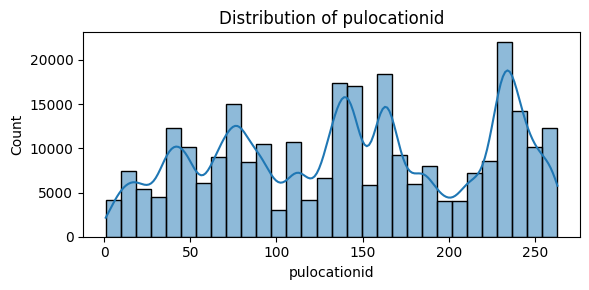

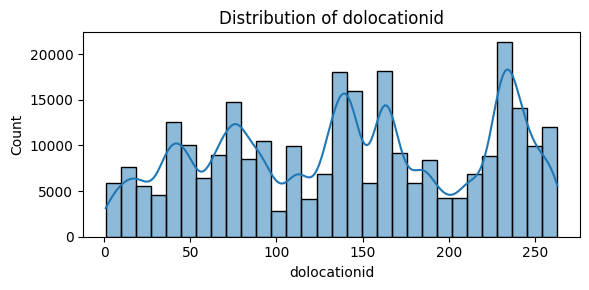

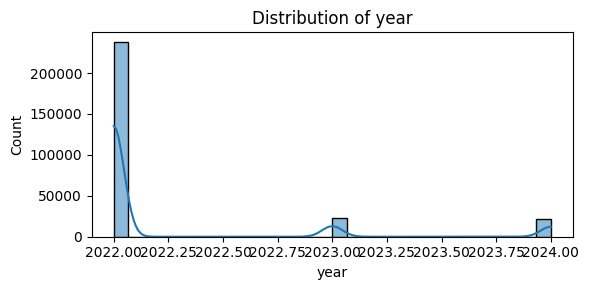

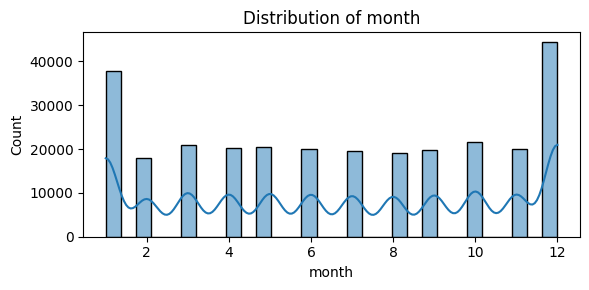

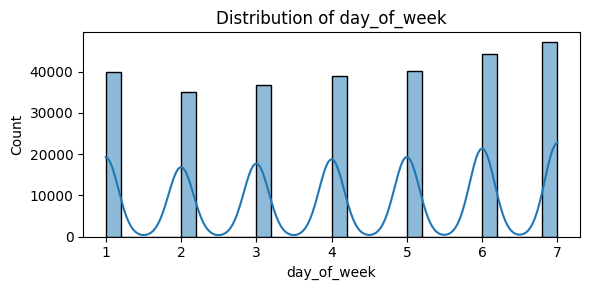

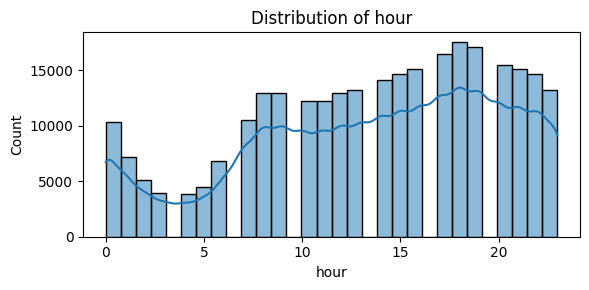

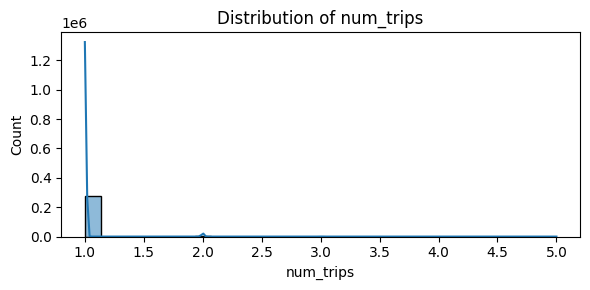

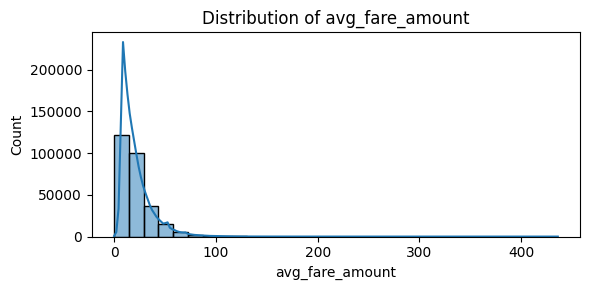

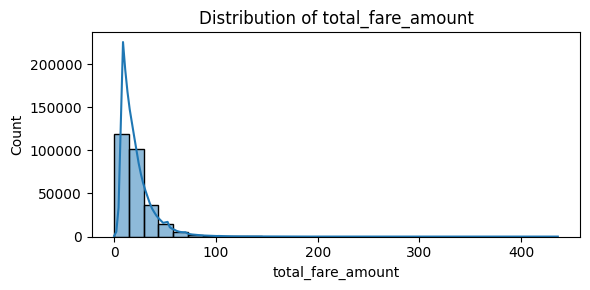

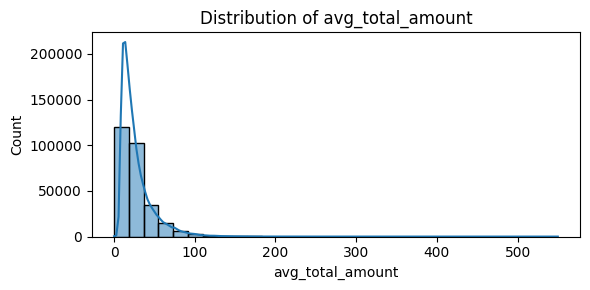

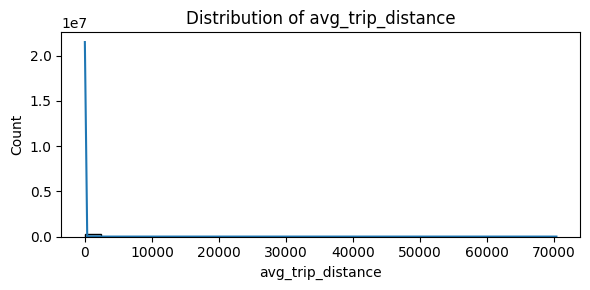

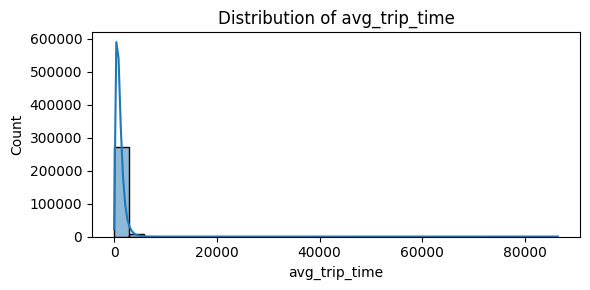

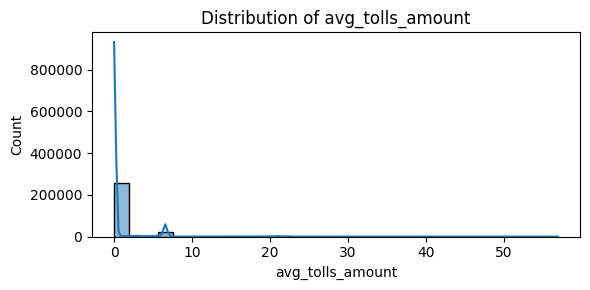

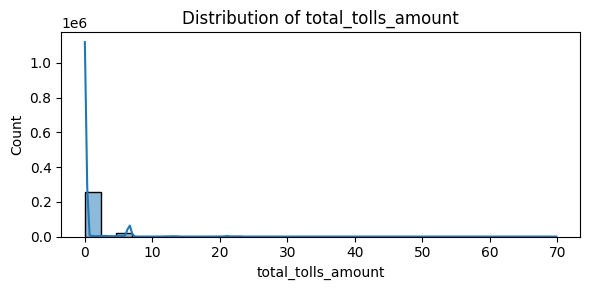

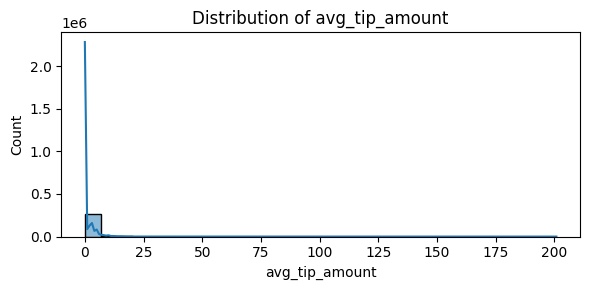

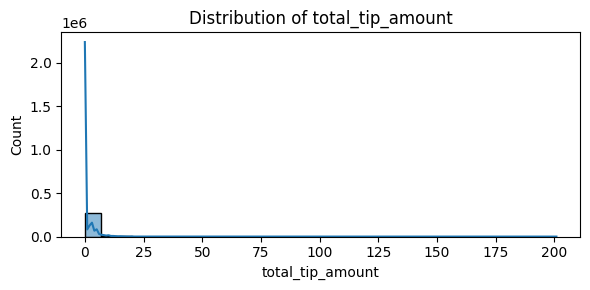

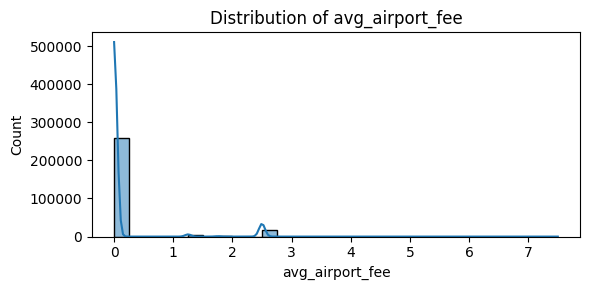

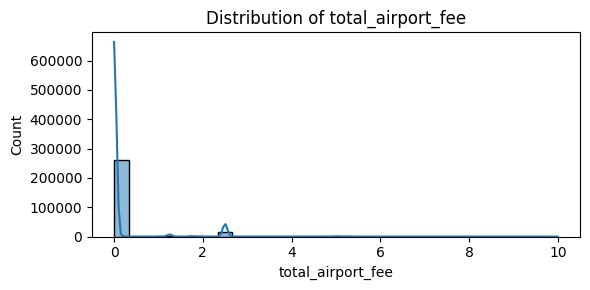

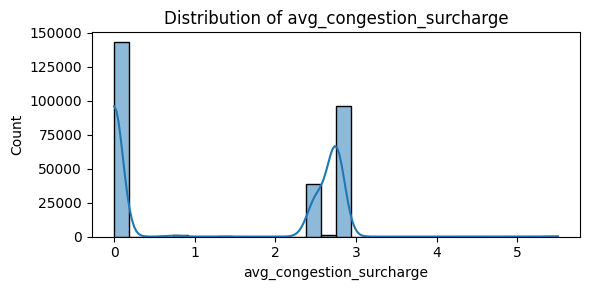

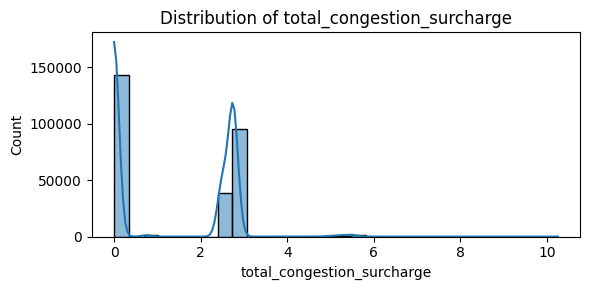

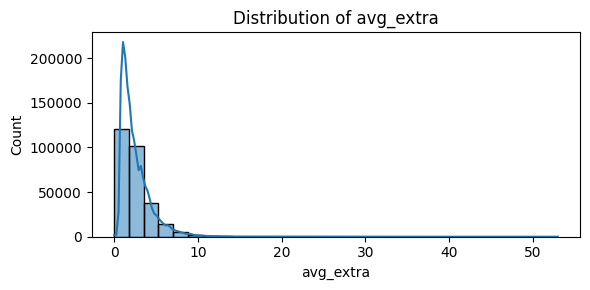

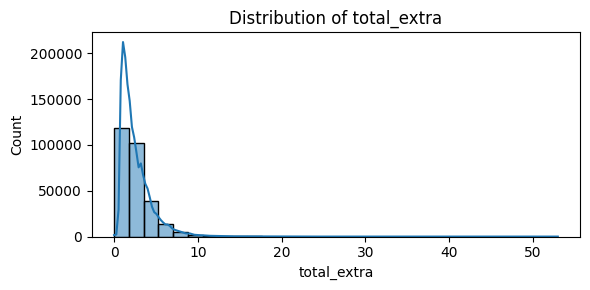

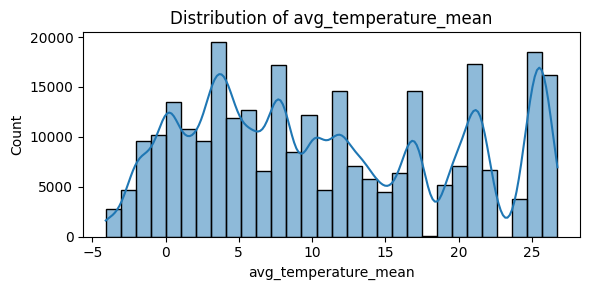

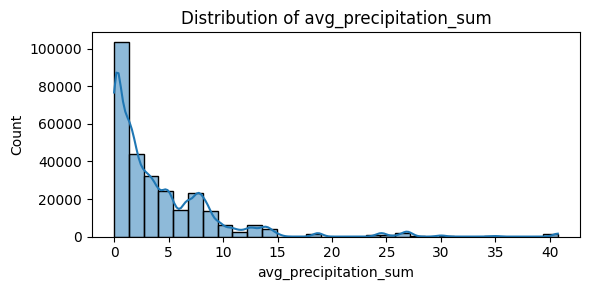

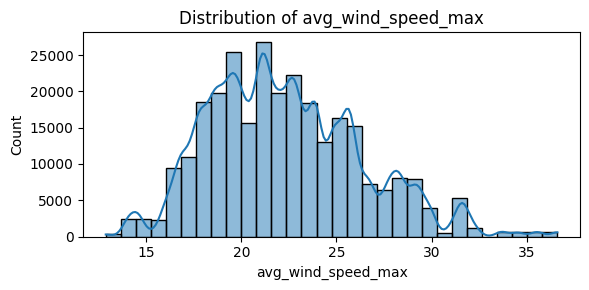

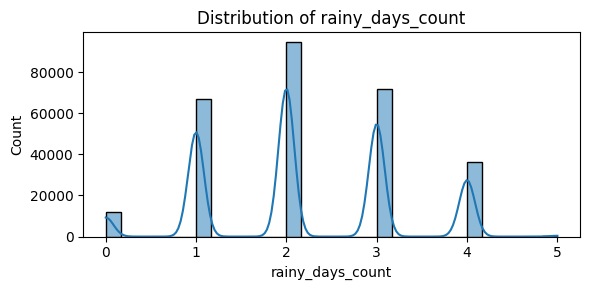

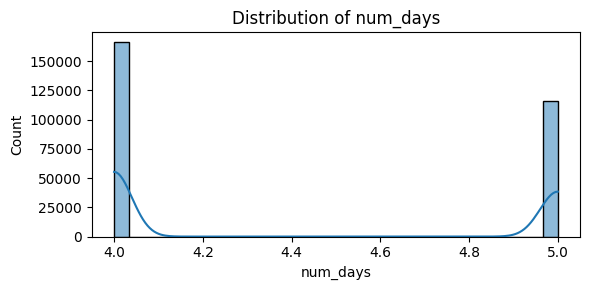

In [7]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

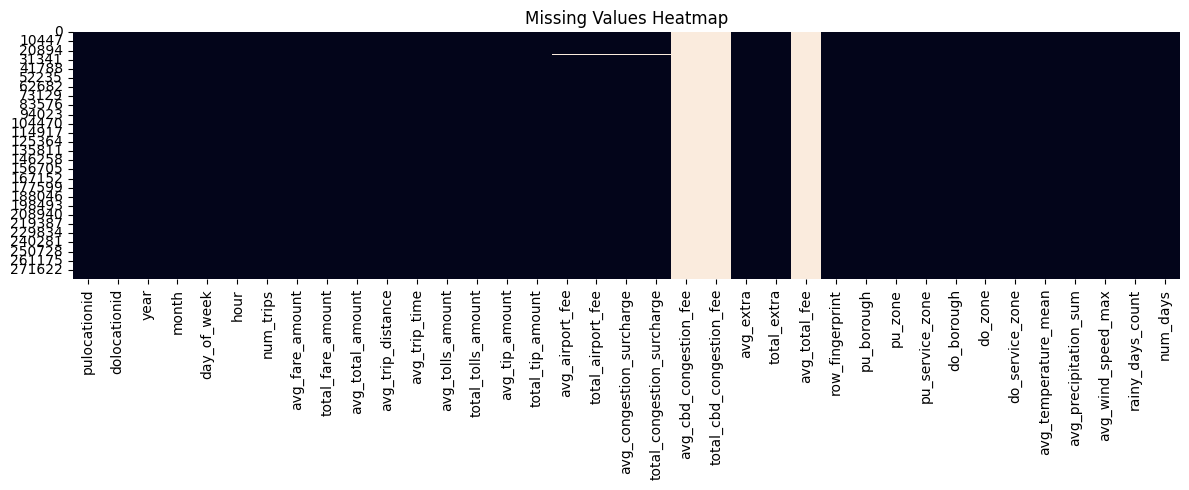

In [8]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

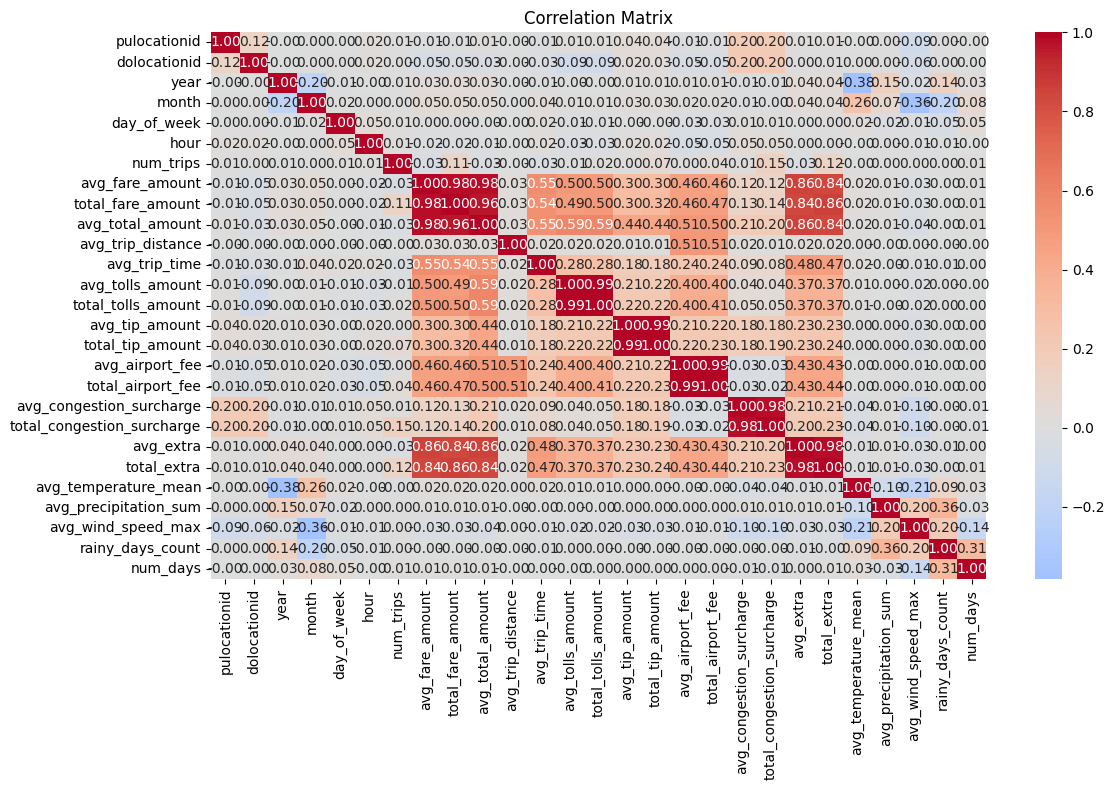

In [9]:
if len(num_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[num_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

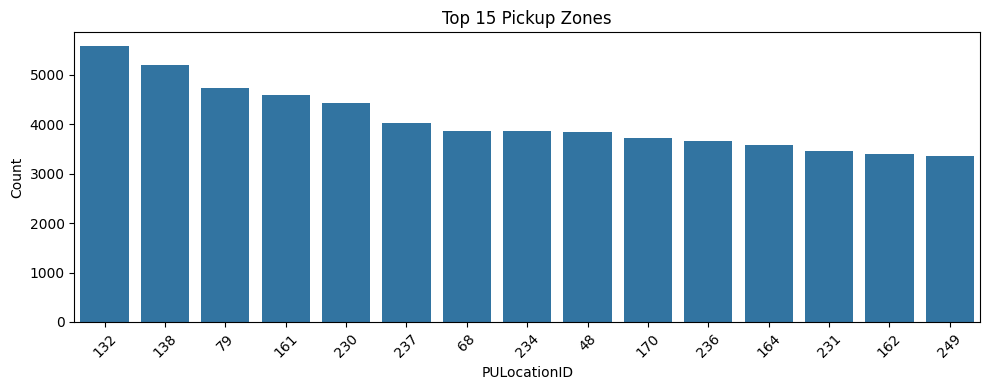

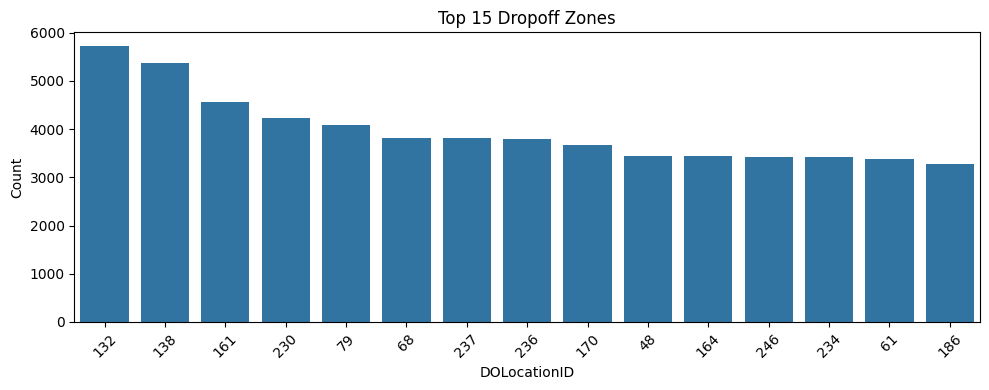

In [10]:
if "pulocationid" in df.columns:
    pickup_counts = df["pulocationid"].value_counts().head(15)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=pickup_counts.index.astype(str), y=pickup_counts.values)
    plt.title("Top 15 Pickup Zones")
    plt.xlabel("PULocationID")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if "dolocationid" in df.columns:
    dropoff_counts = df["dolocationid"].value_counts().head(15)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=dropoff_counts.index.astype(str), y=dropoff_counts.values)
    plt.title("Top 15 Dropoff Zones")
    plt.xlabel("DOLocationID")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Temporal Patterns

In [11]:
time_cols = ["year", "month", "day_of_week", "hour"]
existing_time_cols = [c for c in time_cols if c in df.columns]
print("Available time columns:", existing_time_cols)

Available time columns: ['year', 'month', 'day_of_week', 'hour']


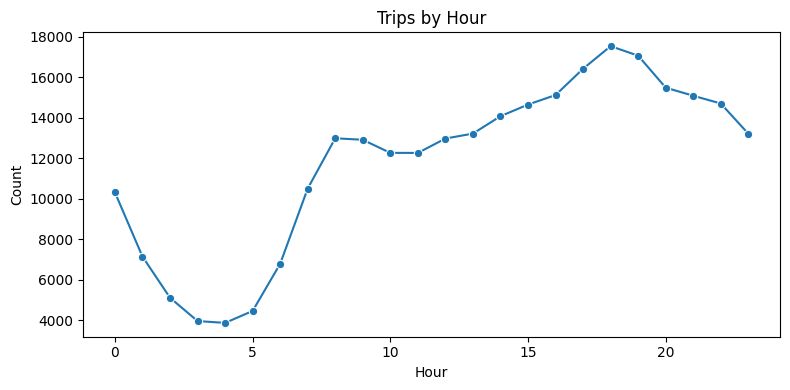

In [12]:
if "hour" in df.columns:
    hourly = df.groupby("hour").size().sort_index()
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=hourly.index, y=hourly.values, marker="o")
    plt.title("Trips by Hour")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

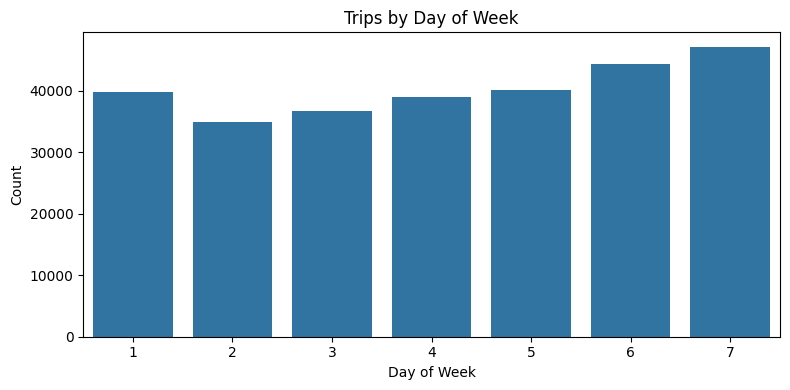

In [13]:
if "day_of_week" in df.columns:
    dow = df.groupby("day_of_week").size().sort_index()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=dow.index.astype(str), y=dow.values)
    plt.title("Trips by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

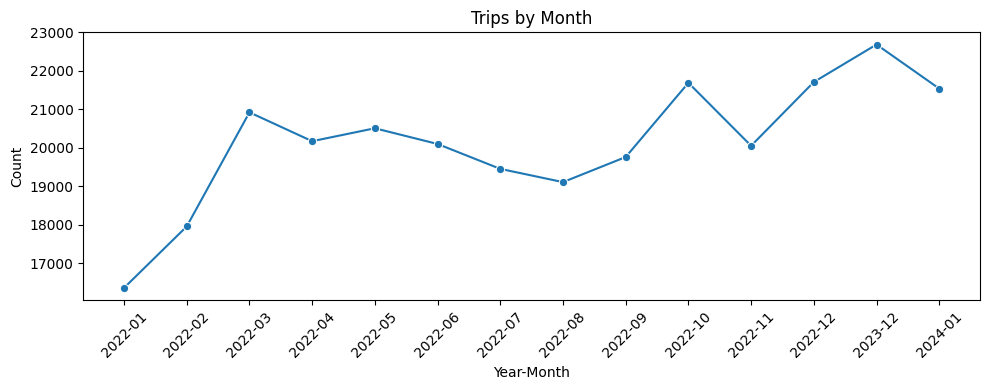

In [14]:
if set(["year", "month"]).issubset(df.columns):
    monthly = df.groupby(["year", "month"]).size().reset_index(name="count")
    monthly["year_month"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=monthly, x="year_month", y="count", marker="o")
    plt.title("Trips by Month")
    plt.xlabel("Year-Month")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4. Trip Characteristics

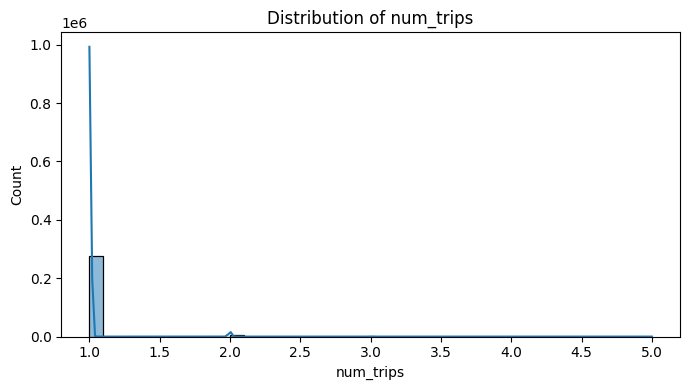

Top rows by num_trips:


,pulocationid,dolocationid,year,month,day_of_week,hour,num_trips,avg_fare_amount,total_fare_amount,avg_total_amount,avg_trip_distance,avg_trip_time,avg_tolls_amount,total_tolls_amount,avg_tip_amount,total_tip_amount,avg_airport_fee,total_airport_fee,avg_congestion_surcharge,total_congestion_surcharge,avg_cbd_congestion_fee,total_cbd_congestion_fee,avg_extra,total_extra,avg_total_fee,row_fingerprint,pu_borough,pu_zone,pu_service_zone,do_borough,do_zone,do_service_zone,avg_temperature_mean,avg_precipitation_sum,avg_wind_speed_max,rainy_days_count,num_days
12161,76,76,2023,12,7,12,5,9.932000,49.66,11.860000,1.460800,478.600000,0.0,0.0,0.800000,4.00,0.0,0.0,0.000000,0.00,None,None,1.128000,5.64,None,c20ce84739c2c94c659db00f42d4ba652de7bf69bcc33f...,Brooklyn,East New York,Boro Zone,Brooklyn,East New York,Boro Zone,7.880,12.840,22.580,3,5
44293,237,236,2022,2,5,15,4,10.882500,43.53,16.402500,0.992500,550.250000,0.0,0.0,1.732500,6.93,0.0,0.0,2.562500,10.25,None,None,2.475000,9.90,None,c8694f215d3050cdfbaade3aecaa43a15b8ae0bb4cefee...,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,5.200,3.825,25.650,2,4
9719,76,76,2023,12,7,14,4,11.160000,44.64,12.407500,1.844250,708.750000,0.0,0.0,0.000000,0.00,0.0,0.0,0.000000,0.00,None,None,1.247500,4.99,None,81aba2ca3c3446926b8b9bda86914537ff17d40023fd56...,Brooklyn,East New York,Boro Zone,Brooklyn,East New York,Boro Zone,7.880,12.840,22.580,3,5
273213,74,42,2022,12,6,21,3,8.580000,25.74,9.596667,1.382667,436.000000,0.0,0.0,0.000000,0.00,0.0,0.0,0.000000,0.00,None,None,1.016667,3.05,None,c1bc1709ac2deb03d6c7cdd4216f1833d7088ea7230f39...,Manhattan,East Harlem North,Boro Zone,Manhattan,Central Harlem North,Boro Zone,3.900,7.660,24.720,2,5
59705,249,161,2022,2,6,8,3,20.366667,61.10,25.533333,2.094333,726.000000,0.0,0.0,0.000000,0.00,0.0,0.0,2.750000,8.25,None,None,2.416667,7.25,None,fa9eed854346b66a0735abf4f9d11baadc27c8e0dfc4ee...,Manhattan,West Village,Yellow Zone,Manhattan,Midtown Center,Yellow Zone,4.050,14.100,31.575,3,4
219990,170,161,2022,10,4,17,3,15.263333,45.79,20.460000,0.810000,670.666667,0.0,0.0,0.333333,1.00,0.0,0.0,2.666667,8.00,None,None,3.030000,9.09,None,005631a96bdf1a092cc2281785cb8f672fcafdaa7874ef...,Manhattan,Murray Hill,Yellow Zone,Manhattan,Midtown Center,Yellow Zone,13.775,2.675,22.775,2,4
140402,237,236,2022,6,4,18,3,5.000000,15.00,11.486667,0.926667,234.666667,0.0,0.0,2.186667,6.56,0.0,0.0,2.500000,5.00,None,None,1.800000,5.40,None,8d727123b6f4374415479180489259893d85aea16f84f2...,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,20.940,3.460,23.780,3,5
44274,161,237,2022,2,4,19,3,7.000000,21.00,13.036667,1.463333,454.000000,0.0,0.0,1.736667,5.21,0.0,0.0,2.500000,7.50,None,None,2.633333,7.90,None,69f8484b4b65a69bc623b2447c49716145f7a5fea8ddbb...,Manhattan,Midtown Center,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,3.400,0.025,19.375,1,4
199467,230,142,2022,9,3,17,3,10.680000,32.04,15.020000,1.050000,554.333333,0.0,0.0,0.000000,0.00,0.0,0.0,2.666667,8.00,None,None,2.506667,7.52,None,74c5c48a1b990f4b953df75e0f807f248e054e542f2516...,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Lincoln Square East,Yellow Zone,20.725,9.850,19.675,2,4
119780,236,237,2022,4,3,16,3,6.500000,19.50,12.416667,0.746667,470.333333,0.0,0.0,1.616667,4.85,0.0,0.0,2.500000,7.50,None,None,3.466667,10.40,None,843860a4809e598d803597c2d19cd7cd0c98ef26cdf7e0...,Manhattan,Upper East Side North,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,10.075,8.475,22.100,4,4


In [15]:
if "num_trips" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df["num_trips"], bins=40, kde=True)
    plt.title("Distribution of num_trips")
    plt.tight_layout()
    plt.show()

    print("Top rows by num_trips:")
    display(df.sort_values("num_trips", ascending=False).head(10))

In [16]:
df["trip_distance"].describe()

KeyError: 'trip_distance'

In [ ]:
df["trip_distance"].hist(bins=50)

In [ ]:
df["fare_amount"].describe()

In [ ]:
df["fare_amount"].hist(bins=50)

In [ ]:
# distance vs fare
df.plot.scatter(
    x="trip_distance",
    y="fare_amount",
    alpha=0.3,
    title="Fare vs Distance"
)

In [ ]:
df["trip_duration_min"] = (
    pd.to_datetime(df["dropoff_datetime"]) - df["pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration_min"].describe()

In [ ]:
df["speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60)
df["speed_mph"].describe()

# 5. Weather Impact

In [ ]:
df["precipitation_sum"].describe()

In [ ]:
df["is_raining"] = (df["precipitation_sum"] > 0).astype(int)
df.groupby("is_raining").size().plot(kind="bar", title="Trips: Rain vs No Rain")

In [ ]:
df.groupby(pd.cut(df["temperature_mean"], bins=10), observed=True).size().plot(
    kind="bar", figsize=(10,5), title="Trips by Temperature",
)

# 6. Location Analysis

In [ ]:
df["borough"].value_counts().plot(kind="bar", title="Trips by Borough")

In [ ]:
top_zones = (df.groupby("zone").size().sort_values(ascending=False).head(10))
top_zones.plot(kind="barh", figsize=(10,6), title="Top 10 Pickup Zones")

# 7. Correlation Analysis

In [ ]:
numeric_cols = [
    "trip_distance", "fare_amount", "total_amount",
    "trip_duration_min", "speed_mph", "temperature_mean"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")